## 1. Preprocesamiento de Datos
### 1.1 Importar Librerias, carga e inspeccion inicial

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_csv("data/dataset_generacion_anual_de_residuos_solidos_domiciliarios_y_municipales.csv", encoding="latin-1", sep=";")
df = df.rename(columns={"GENERACION_DOM URBANA_TANIO": "GENERACION_DOM_URBANA_TANIO"})
df.head()

,FECHA_CORTE,UBIGEO,ANIO,DEPARTAMENTO,PROVINCIA,DISTRITO,REGION_NATURAL,TIPO_MUNICIPALIDAD,POB_TOTAL_INEI,POB_URBANA_INEI,POB_RURAL_INEI,CLASIFICACION_MUNICIPAL_MEF,GENERACION_PER_CAPITA_DOM,GENERACION_DOM_URBANA_TDIA,GENERACION_DOM_URBANA_TANIO,GENERACION_MUN_TANIO,GENERACION_MUN_TDIA,GENERACION_PER_CAPITA_MUNICIPAL
0,18122025,10101,2024,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,SELVA,PROVINCIAL,41335,40358,977,A,0.50,20.18,7365.34,10521.91,28.83,0.71
1,18122025,10102,2024,AMAZONAS,CHACHAPOYAS,ASUNCION,SELVA,DISTRITAL,271,130,141,F,0.53,0.07,25.15,35.93,0.10,0.76
2,18122025,10103,2024,AMAZONAS,CHACHAPOYAS,BALSAS,SIERRA,DISTRITAL,1137,276,861,G,0.45,0.12,45.33,64.76,0.18,0.64
3,18122025,10104,2024,AMAZONAS,CHACHAPOYAS,CHETO,SIERRA,DISTRITAL,713,448,265,F,0.45,0.20,73.58,105.12,0.29,0.64
4,18122025,10105,2024,AMAZONAS,CHACHAPOYAS,CHILIQUIN,SIERRA,DISTRITAL,561,144,417,G,0.45,0.06,23.65,33.79,0.09,0.64


In [5]:
print("Dimensiones del dataset:", df.shape)

print("\nColumnas disponibles:")
print(df.columns.tolist())
print("\n")

df.info()

Dimensiones del dataset: (11310, 18)

Columnas disponibles:
['FECHA_CORTE', 'UBIGEO', 'ANIO', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'REGION_NATURAL', 'TIPO_MUNICIPALIDAD', 'POB_TOTAL_INEI', 'POB_URBANA_INEI', 'POB_RURAL_INEI', 'CLASIFICACION_MUNICIPAL_MEF', 'GENERACION_PER_CAPITA_DOM', 'GENERACION_DOM_URBANA_TDIA', 'GENERACION_DOM_URBANA_TANIO', 'GENERACION_MUN_TANIO', 'GENERACION_MUN_TDIA', 'GENERACION_PER_CAPITA_MUNICIPAL']


<class 'pandas.DataFrame'>
RangeIndex: 11310 entries, 0 to 11309
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   FECHA_CORTE                      11310 non-null  int64  
 1   UBIGEO                           11310 non-null  int64  
 2   ANIO                             11310 non-null  int64  
 3   DEPARTAMENTO                     11310 non-null  str    
 4   PROVINCIA                        11310 non-null  str    
 5   DISTRITO                    

### 1.2 Tratamiento de valores faltantes
Afortunadamente, este dataset no tiene valores nulos

### 1.3 Deteccion y tratamiento de Outliers (IQR)

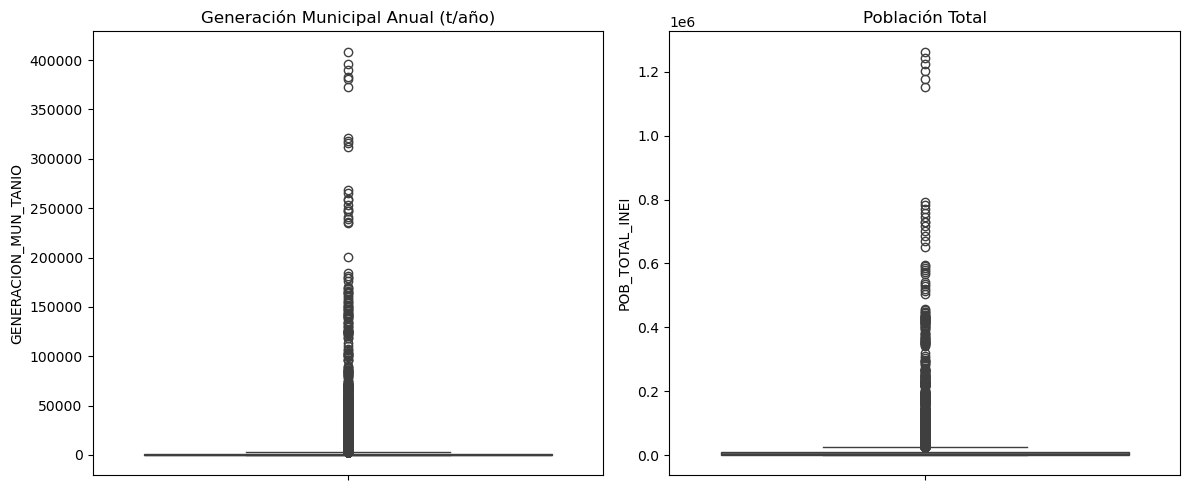

Límites IQR: [-1526.89, 2838.16] toneladas/año
Distritos identificados como outliers: 1880


,DISTRITO,DEPARTAMENTO,GENERACION_MUN_TANIO
1324,SAN JUAN DE LURIGANCHO,LIMA,408652.54
3215,SAN JUAN DE LURIGANCHO,LIMA,396045.05
5105,SAN JUAN DE LURIGANCHO,LIMA,389666.76
6995,SAN JUAN DE LURIGANCHO,LIMA,382679.69
8873,SAN JUAN DE LURIGANCHO,LIMA,380710.63
10747,SAN JUAN DE LURIGANCHO,LIMA,372508.55
5108,SAN MARTIN DE PORRES,LIMA,321502.43
8876,SAN MARTIN DE PORRES,LIMA,318134.52
6998,SAN MARTIN DE PORRES,LIMA,316284.39
10750,SAN MARTIN DE PORRES,LIMA,311814.16


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df["GENERACION_MUN_TANIO"], ax=axes[0])
axes[0].set_title("Generación Municipal Anual (t/año)")
sns.boxplot(y=df["POB_TOTAL_INEI"], ax=axes[1])
axes[1].set_title("Población Total")
plt.tight_layout()
plt.show()

def limites_iqr(serie):
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

lim_inf, lim_sup = limites_iqr(df["GENERACION_MUN_TANIO"])
outliers = df[(df["GENERACION_MUN_TANIO"] < lim_inf) | (df["GENERACION_MUN_TANIO"] > lim_sup)]

print(f"Límites IQR: [{lim_inf:.2f}, {lim_sup:.2f}] toneladas/año")
print(f"Distritos identificados como outliers: {len(outliers)}")
outliers[["DISTRITO", "DEPARTAMENTO", "GENERACION_MUN_TANIO"]].sort_values("GENERACION_MUN_TANIO", ascending=False).head(10)

In [7]:
df["ES_OUTLIER_GENERACION"] = (df["GENERACION_MUN_TANIO"] < lim_inf) | (df["GENERACION_MUN_TANIO"] > lim_sup)

df_normal = df[~df["ES_OUTLIER_GENERACION"]].copy()
df_outliers = df[df["ES_OUTLIER_GENERACION"]].copy()

print(f"Distritos normales (K-Means): {len(df_normal)}")
print(f"Distritos outliers (!K-Means): {len(df_outliers)}")

Distritos normales (K-Means): 9430
Distritos outliers (!K-Means): 1880


### 1.4 Codificacion de variables categoricas

In [8]:
df_normal_encoded = df_normal.copy()

le_region = LabelEncoder()
df_normal_encoded["REGION_NATURAL_COD"] = le_region.fit_transform(df_normal_encoded["REGION_NATURAL"])

df_normal_encoded = pd.get_dummies(df_normal_encoded, columns=["TIPO_MUNICIPALIDAD", "CLASIFICACION_MUNICIPAL_MEF"], prefix=["TIPO", "MEF"])

df_normal_encoded.head()

,FECHA_CORTE,UBIGEO,ANIO,DEPARTAMENTO,PROVINCIA,DISTRITO,REGION_NATURAL,POB_TOTAL_INEI,POB_URBANA_INEI,POB_RURAL_INEI,...,REGION_NATURAL_COD,TIPO_DISTRITAL,TIPO_PROVINCIAL,MEF_B,MEF_C,MEF_D,MEF_E,MEF_F,MEF_G,MEF_No disponible
1,18122025,10102,2024,AMAZONAS,CHACHAPOYAS,ASUNCION,SELVA,271,130,141,...,2,True,False,False,False,False,False,True,False,False
2,18122025,10103,2024,AMAZONAS,CHACHAPOYAS,BALSAS,SIERRA,1137,276,861,...,3,True,False,False,False,False,False,False,True,False
3,18122025,10104,2024,AMAZONAS,CHACHAPOYAS,CHETO,SIERRA,713,448,265,...,3,True,False,False,False,False,False,True,False,False
4,18122025,10105,2024,AMAZONAS,CHACHAPOYAS,CHILIQUIN,SIERRA,561,144,417,...,3,True,False,False,False,False,False,False,True,False
5,18122025,10106,2024,AMAZONAS,CHACHAPOYAS,CHUQUIBAMBA,SIERRA,1884,437,1447,...,3,True,False,False,False,False,False,False,True,False


**Nota (Jhair)** La categoría MEF "A" no aparece en `df_normal` porque corresponde a las
municipalidades de mayor envergadura (Lima y otras ciudades principales), las cuales
ya fueron separadas como outliers en la etapa de detección de IQR. Esto confirma la
coherencia entre ambos criterios de clasificación.

In [10]:
print("Categorias MEF en df_normal:", sorted(df_normal["CLASIFICACION_MUNICIPAL_MEF"].unique()))
print("Categorias MEF en df_outliers:", sorted(df_outliers["CLASIFICACION_MUNICIPAL_MEF"].unique()))

Categorias MEF en df_normal: ['B', 'C', 'D', 'E', 'F', 'G', 'No disponible']
Categorias MEF en df_outliers: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'No disponible']


### 1.5 Normalizacion

In [11]:
variables_numericas = ["GENERACION_MUN_TANIO", "GENERACION_PER_CAPITA_MUNICIPAL", "POB_TOTAL_INEI"]

scaler = StandardScaler()
df_normal_scaled = df_normal_encoded.copy()
df_normal_scaled[variables_numericas] = scaler.fit_transform(df_normal_encoded[variables_numericas])

df_normal_scaled[variables_numericas].describe()

,GENERACION_MUN_TANIO,GENERACION_PER_CAPITA_MUNICIPAL,POB_TOTAL_INEI
count,9.430000e+03,9.430000e+03,9.430000e+03
mean,-1.205587e-17,1.175447e-16,7.760965e-17
std,1.000053e+00,1.000053e+00,1.000053e+00
min,-7.742959e-01,-3.122966e+00,-9.190228e-01
25%,-6.193133e-01,-1.684583e-01,-6.851849e-01
50%,-4.095958e-01,-1.042299e-01,-3.595678e-01
75%,1.577298e-01,4.095976e-01,3.563917e-01
max,4.249265e+00,1.421871e+01,6.740407e+00


**Nota (Jhair)** 
Esta de abajo es la tabla con valores normalizados redondeados

In [12]:
tabla_normalizacion = df_normal_scaled[variables_numericas].describe().round(2)
tabla_normalizacion

,GENERACION_MUN_TANIO,GENERACION_PER_CAPITA_MUNICIPAL,POB_TOTAL_INEI
count,9430.00,9430.00,9430.00
mean,-0.00,0.00,0.00
std,1.00,1.00,1.00
min,-0.77,-3.12,-0.92
25%,-0.62,-0.17,-0.69
50%,-0.41,-0.10,-0.36
75%,0.16,0.41,0.36
max,4.25,14.22,6.74
